## Early Stopping

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score

In [19]:
df = pd.read_csv("data1/sonar.all-data", header=None)
df.sample(3)

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
109,0.0264,0.0071,0.0342,0.0793,0.1043,0.0783,0.1417,0.1176,0.0453,0.0945,...,0.0214,0.0262,0.0177,0.0037,0.0068,0.0121,0.0077,0.0078,0.0066,M
179,0.0394,0.0420,0.0446,0.0551,0.0597,0.1416,0.0956,0.0802,0.1618,0.2558,...,0.0146,0.0040,0.0114,0.0032,0.0062,0.0101,0.0068,0.0053,0.0087,M
126,0.0715,0.0849,0.0587,0.0218,0.0862,0.1801,0.1916,0.1896,0.2960,0.4186,...,0.0153,0.0121,0.0096,0.0196,0.0042,0.0066,0.0099,0.0083,0.0124,M


In [20]:
df.shape

(208, 61)

In [21]:
df[60].value_counts()

60
M    111
R     97
Name: count, dtype: int64

In [22]:
df[60] = df[60].map({'M' : 0, 'R' : 1})
df.head(3)

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,1
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,1
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,1


In [23]:
X = df.drop(60, axis=1)
y = df[60]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [24]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [25]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

In [26]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(60, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.network(x)

In [27]:
# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=20):
    train_losses, val_losses, val_accuracies = [], [], []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_losses.append(running_loss / len(train_loader))
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        y_pred, y_true = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                y_pred.extend(predicted.cpu().numpy())
                y_true.extend(labels.cpu().numpy())
        val_losses.append(val_loss / len(val_loader))
        val_accuracy = accuracy_score(y_true, y_pred)
        val_accuracies.append(val_accuracy)
        
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Accuracy: {val_accuracy:.4f}")
    
    return train_losses, val_losses, val_accuracies

Epoch 1/20, Train Loss: 0.6884, Val Loss: 0.6868, Val Accuracy: 0.4762
Epoch 2/20, Train Loss: 0.6814, Val Loss: 0.6864, Val Accuracy: 0.4762
Epoch 3/20, Train Loss: 0.6696, Val Loss: 0.6722, Val Accuracy: 0.5714
Epoch 4/20, Train Loss: 0.6513, Val Loss: 0.6570, Val Accuracy: 0.6190
Epoch 5/20, Train Loss: 0.6294, Val Loss: 0.6349, Val Accuracy: 0.6429
Epoch 6/20, Train Loss: 0.6017, Val Loss: 0.5829, Val Accuracy: 0.7143
Epoch 7/20, Train Loss: 0.5625, Val Loss: 0.5596, Val Accuracy: 0.6905
Epoch 8/20, Train Loss: 0.5133, Val Loss: 0.4968, Val Accuracy: 0.7857
Epoch 9/20, Train Loss: 0.4868, Val Loss: 0.5501, Val Accuracy: 0.7143
Epoch 10/20, Train Loss: 0.4657, Val Loss: 0.5215, Val Accuracy: 0.7619
Epoch 11/20, Train Loss: 0.4103, Val Loss: 0.4555, Val Accuracy: 0.7381
Epoch 12/20, Train Loss: 0.3956, Val Loss: 0.4638, Val Accuracy: 0.7381
Epoch 13/20, Train Loss: 0.4141, Val Loss: 0.5186, Val Accuracy: 0.7143
Epoch 14/20, Train Loss: 0.3880, Val Loss: 0.4900, Val Accuracy: 0.7381
E

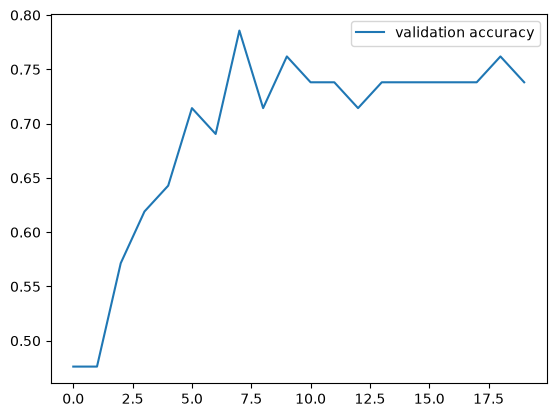

In [28]:
model = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_losses, val_losses, val_accuracies = train_model(model, train_loader, test_loader, criterion, optimizer, epochs=20)

plt.plot(val_accuracies, label="validation accuracy")
plt.legend()
plt.show()


### Early Stopping

In [29]:
# Training function
def train_model_early_stop(model, train_loader, val_loader, criterion, optimizer, epochs=20):
    
    patience = 3
    best_accuracy = 0
    counter = 0
    
    train_losses, val_losses, val_accuracies = [], [], []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_losses.append(running_loss / len(train_loader))
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        y_pred, y_true = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                y_pred.extend(predicted.cpu().numpy())
                y_true.extend(labels.cpu().numpy())
        val_losses.append(val_loss / len(val_loader))
        val_accuracy = accuracy_score(y_true, y_pred)
        val_accuracies.append(val_accuracy)
        
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Accuracy: {val_accuracy:.4f}")
    
        
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            counter = 0
            torch.save(model.state_dict(), "best_model.pt")
        else:
            counter += 1
            if counter >= patience:
                print(f"Early Stopping at Epoch {epoch+1}")
                break
    
    return train_losses, val_losses, val_accuracies

Epoch 1/20, Train Loss: 0.6873, Val Loss: 0.6881, Val Accuracy: 0.4762
Epoch 2/20, Train Loss: 0.6744, Val Loss: 0.6787, Val Accuracy: 0.4762
Epoch 3/20, Train Loss: 0.6540, Val Loss: 0.6562, Val Accuracy: 0.5952
Epoch 4/20, Train Loss: 0.6456, Val Loss: 0.6464, Val Accuracy: 0.5476
Epoch 5/20, Train Loss: 0.6167, Val Loss: 0.5798, Val Accuracy: 0.7381
Epoch 6/20, Train Loss: 0.5764, Val Loss: 0.5667, Val Accuracy: 0.7143
Epoch 7/20, Train Loss: 0.5361, Val Loss: 0.5384, Val Accuracy: 0.6905
Epoch 8/20, Train Loss: 0.5105, Val Loss: 0.5040, Val Accuracy: 0.7857
Epoch 9/20, Train Loss: 0.4850, Val Loss: 0.4908, Val Accuracy: 0.7381
Epoch 10/20, Train Loss: 0.4628, Val Loss: 0.5002, Val Accuracy: 0.7619
Epoch 11/20, Train Loss: 0.4160, Val Loss: 0.4525, Val Accuracy: 0.7381
Early Stopping at Epoch 11


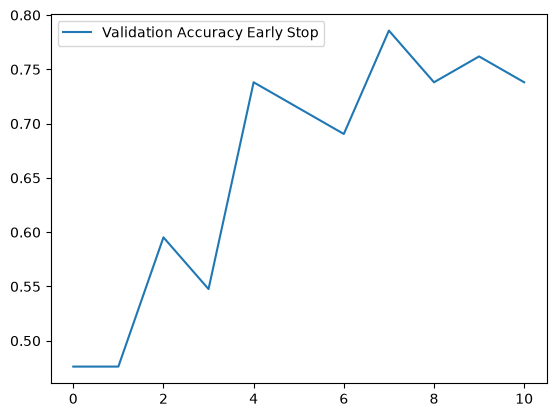

In [30]:
# Initialize and train the model 
model = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses, val_accuracies = train_model_early_stop(
    model, train_loader, test_loader, criterion, optimizer, epochs=20
)

plt.plot(val_accuracies, label="Validation Accuracy Early Stop")
plt.legend()
plt.show()

In [31]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [32]:
# Validation phase
model.eval()
y_pred, y_true = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, predicted = torch.max(outputs, 1)
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.cpu().numpy())
val_accuracy = accuracy_score(y_true, y_pred)
val_accuracy

0.7857142857142857